In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

I0000 00:00:1789722875.031986    2487 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pathlib

train_data_dir = "../data/raw/Howard-Cloud-X/train"
train_data_dir = pathlib.Path(train_data_dir).with_suffix('')
val_data_dir = "../data/raw/Howard-Cloud-X/test"
val_data_dir = pathlib.Path(val_data_dir).with_suffix('')

In [3]:
image_count = len(list(train_data_dir.glob('*/*.jpg')))
print(image_count)

1087


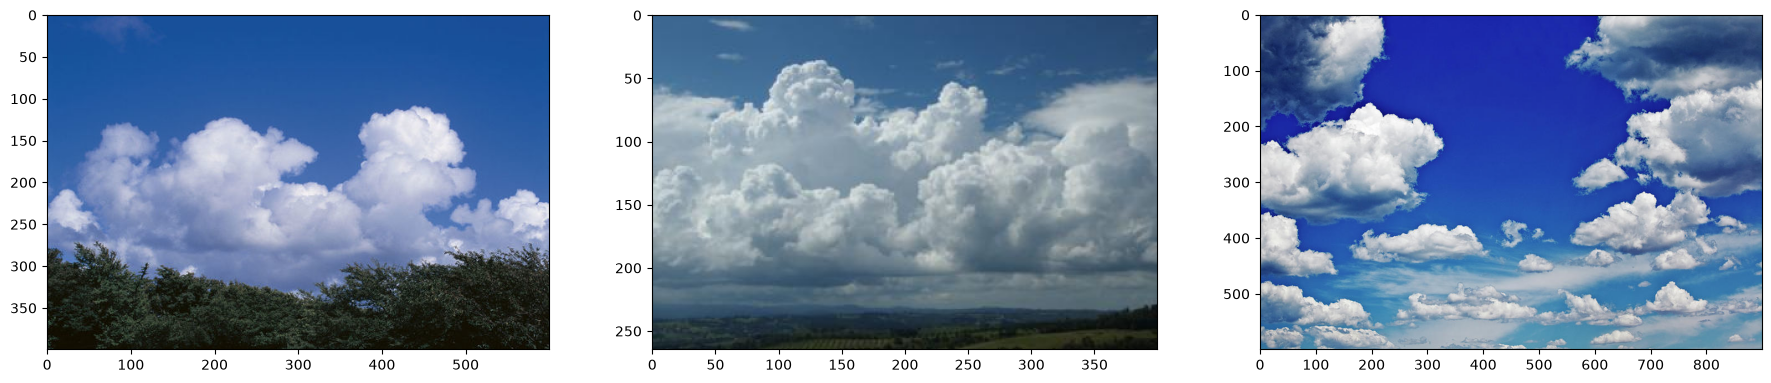

In [4]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Cumulus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

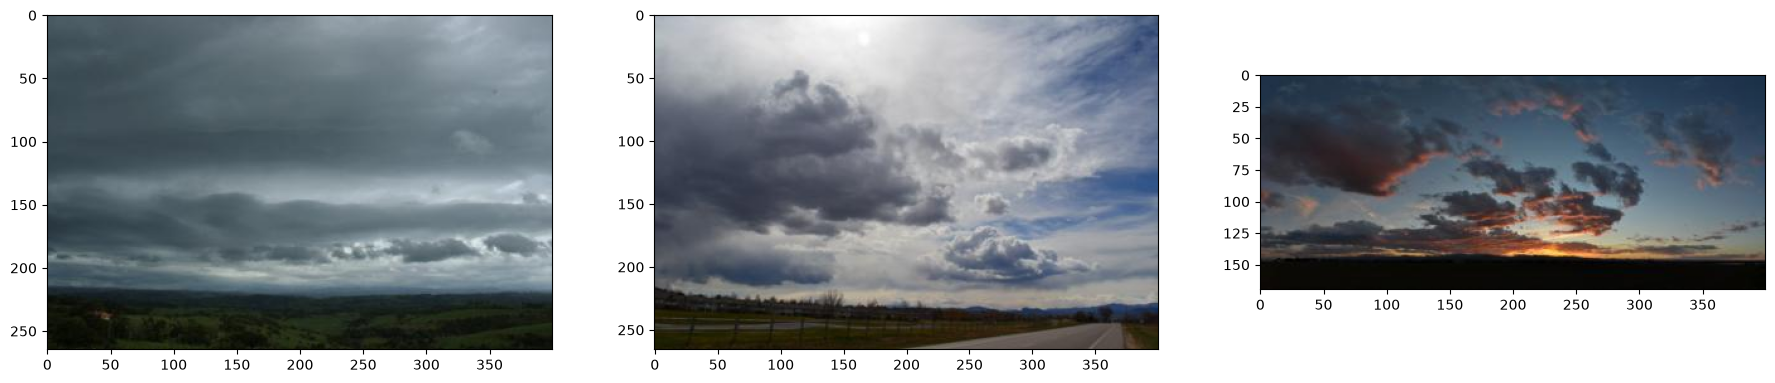

In [5]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Stratus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

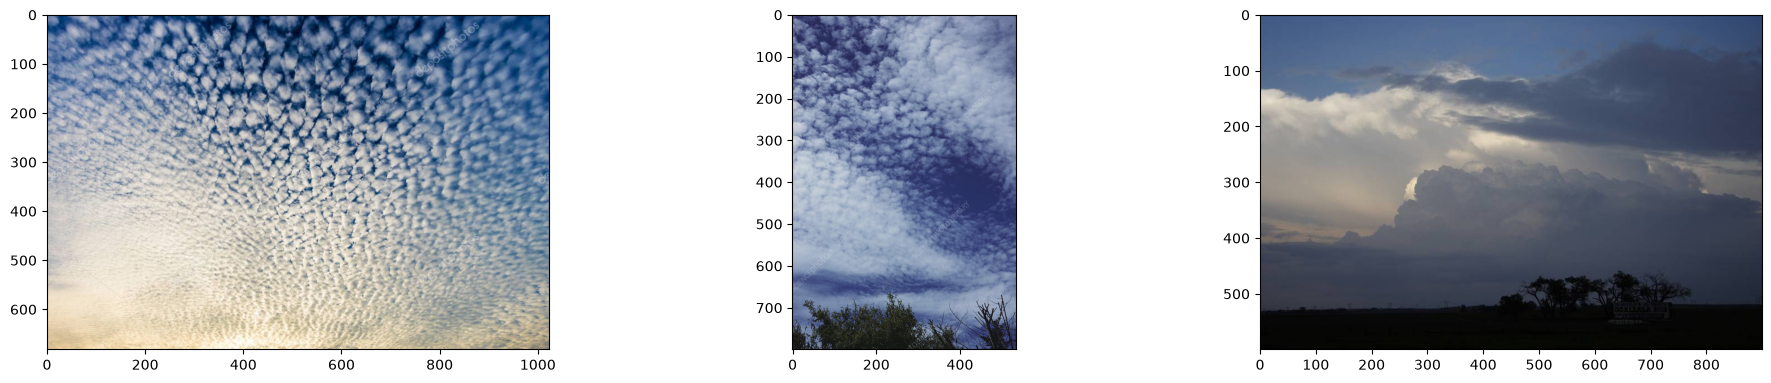

In [6]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Altocumulus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

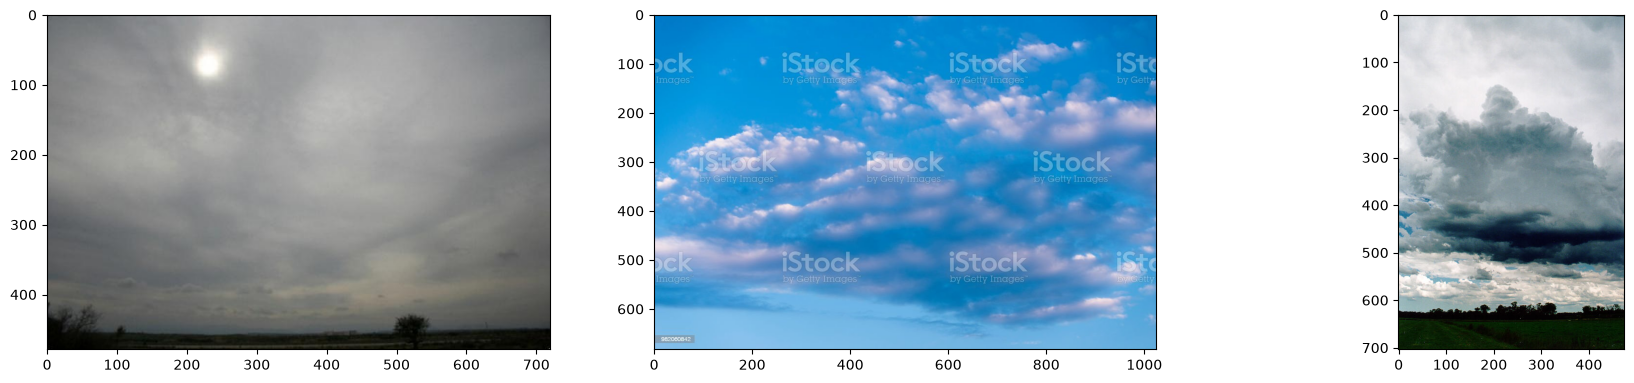

In [7]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Altostratus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

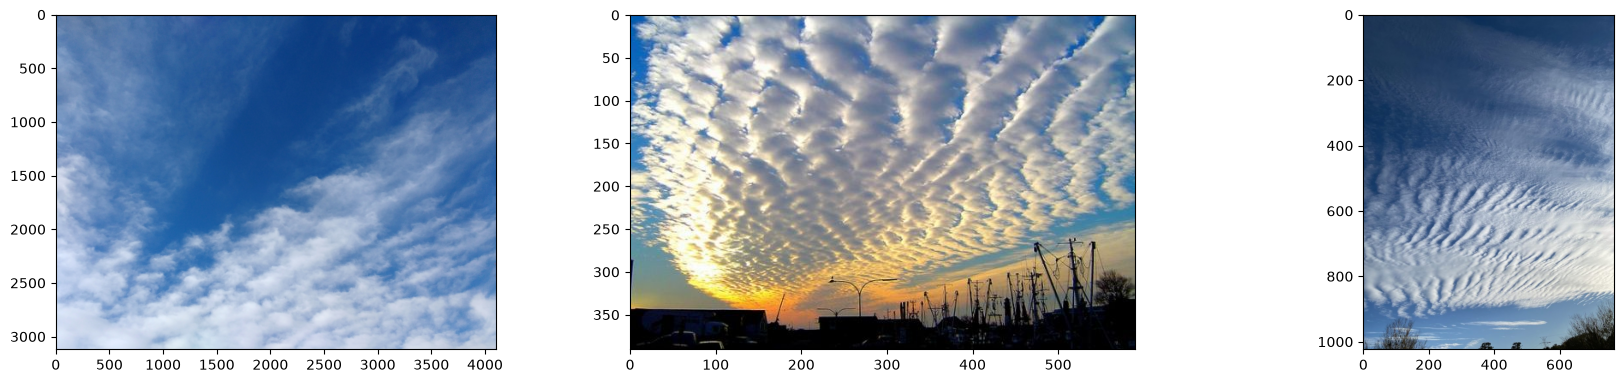

In [8]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Cirroculumulus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

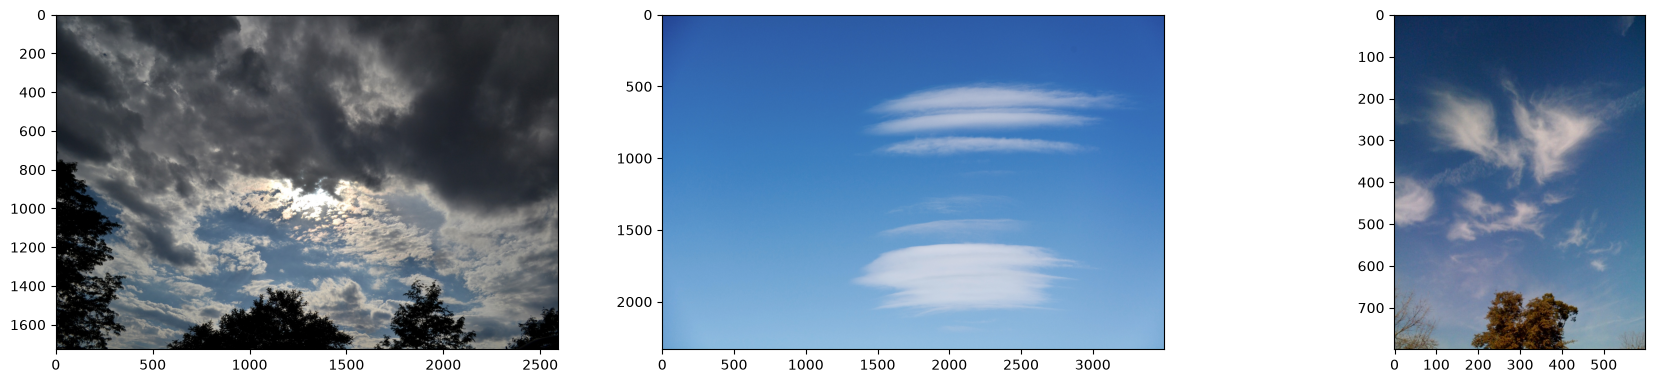

In [9]:
import matplotlib.pyplot as plt
roses = list(train_data_dir.glob('Cirrus/*'))
j= 0
fig = plt.figure(figsize= (30, 20))
for i in roses[:3]:
    ax = fig.add_subplot(4, 4, j+1)
    img = PIL.Image.open(str(i))
    rgb_pixels = np.array(img)
    ax.imshow(rgb_pixels)
    j+=1

In [10]:
batch_size = 32
img_height = 224
img_width = 224

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_data_dir,
  validation_split=0.3,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1170 files belonging to 10 classes.
Using 1053 files for training.


I0000 00:00:1789722885.081127    2487 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:2b:00.0, compute capability: 8.6


In [12]:
class_names = train_ds.class_names
print(class_names)

['Altocumulus', 'Altostratus', 'Cirroculumulus', 'Cirrostratus', 'Cirrus', 'Cumulonimbus', 'Cumulus', 'Nimbostratus', 'Stratocumulus', 'Stratus']


In [13]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [14]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 250 files belonging to 10 classes.
Using 25 files for validation.


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [16]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40


/home/linux/Cloud-Recognizer/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1789722897.815996    2595 cuda_dnn.cc:461] Loaded cuDNN version 92600


33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.1425 - loss: 2.3619 - val_accuracy: 0.1600 - val_loss: 2.3141
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2479 - loss: 2.0977 - val_accuracy: 0.2400 - val_loss: 2.1722
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2953 - loss: 1.9753 - val_accuracy: 0.2400 - val_loss: 2.2199
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3533 - loss: 1.8618 - val_accuracy: 0.2800 - val_loss: 2.1513
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3694 - loss: 1.7848 - val_accuracy: 0.2800 - val_loss: 2.1420
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4008 - loss: 1.7205 - val_accuracy: 0.2800 - val_loss: 2.1605
Epoch 7/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4444 - loss: 1.6739 - val_accuracy: 0.2400 - val_loss: 2.1378
Epoch 8/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4729 - loss: 1.6037 - val_accuracy: 0.2400 - val_loss: 2

In [18]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
early_stopping_fine = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_fine]
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.3086 - loss: 2.2247 - val_accuracy: 0.2400 - val_loss: 2.0438
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3428 - loss: 2.0862 - val_accuracy: 0.2400 - val_loss: 2.0522
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3637 - loss: 1.9510 - val_accuracy: 0.2400 - val_loss: 2.0619
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.3666 - loss: 1.9088 - val_accuracy: 0.2400 - val_loss: 2.0711
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3913 - loss: 1.8296 - val_accuracy: 0.2400 - val_loss: 2.0773
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3837 - loss: 1.7816 - val_accuracy: 0.2400 - val_loss: 2.0845


In [21]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds_raw.class_names

print(class_names)

Found 1170 files belonging to 10 classes.
Using 819 files for training.
['Altocumulus', 'Altostratus', 'Cirroculumulus', 'Cirrostratus', 'Cirrus', 'Cumulonimbus', 'Cumulus', 'Nimbostratus', 'Stratocumulus', 'Stratus']


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

print(cm)

                precision    recall  f1-score   support

   Altocumulus       0.00      0.00      0.00         1
   Altostratus       0.33      0.50      0.40         2
Cirroculumulus       0.00      0.00      0.00         3
  Cirrostratus       0.00      0.00      0.00         4
        Cirrus       1.00      0.60      0.75         5
  Cumulonimbus       0.00      0.00      0.00         1
       Cumulus       0.00      0.00      0.00         2
  Nimbostratus       0.00      0.00      0.00         0
 Stratocumulus       1.00      0.33      0.50         3
       Stratus       1.00      0.25      0.40         4

      accuracy                           0.24        25
     macro avg       0.33      0.17      0.20        25
  weighted avg       0.51      0.24      0.31        25

[[0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [2 1 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 2 0 0 0]
 [1 0 0 1 3 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 1 0]
 [0 0 

/home/linux/Cloud-Recognizer/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/linux/Cloud-Recognizer/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/linux/Cloud-Recognizer/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result